# 📊 Query Generation Analysis — Multi-Model Edition

Deep-dive into generated **PANDAS** and **SQL** queries across multiple LLM providers:  
success rates, response production, token costs, generation speed, keyword patterns and more.

> **New in this version:** model-level breakdowns · response-production tracking · token budget analysis · generation-time profiling

---
## 0. Setup & Data Loading

In [2]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter
from pathlib import Path

# ── Global style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PALETTE = {
    'success':     '#2ECC71',
    'failure':     '#E74C3C',
    'PANDAS':      '#3498DB',
    'SQL':         '#9B59B6',
    'simple':      '#1ABC9C',
    'hard':        '#F39C12',
    'challenging': '#E74C3C',
    # response production
    'with_response':    '#27AE60',
    'without_response': '#C0392B',
}

# Distinct model colours (up to 10)
MODEL_COLORS = [
    '#2980B9','#8E44AD','#16A085','#D35400',
    '#2C3E50','#C0392B','#27AE60','#F39C12',
    '#1ABC9C','#E91E63',
]

DIFF_ORDER = ['simple', 'hard', 'challenging']

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = r'D:\orqa\socrata\nyc\candidates_discovery\generated_queries.json'
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

models = list(raw.keys())
MODEL_PALETTE = {m: MODEL_COLORS[i % len(MODEL_COLORS)] for i, m in enumerate(models)}

print(f'Models found: {models}')
for model, langs in raw.items():
    for lang, entries in langs.items():
        print(f'  {model} / {lang}: {len(entries)} entries')


Models found: ['google.gemini-2.5-pro', 'meta.llama-3.3-70b-instruct', 'openai.gpt-oss-120b']
  google.gemini-2.5-pro / SQL: 107 entries
  google.gemini-2.5-pro / PANDAS: 107 entries
  meta.llama-3.3-70b-instruct / PANDAS: 107 entries
  meta.llama-3.3-70b-instruct / SQL: 107 entries
  openai.gpt-oss-120b / SQL: 107 entries
  openai.gpt-oss-120b / PANDAS: 107 entries


---
## 1. Flatten to DataFrames

In [3]:
# ── Flatten into tidy DataFrames ───────────────────────────────────────────────
records_entry = []   # one row per (model, language, entry_id)
records_query = []   # one row per (model, language, entry_id, query_index)

for model, langs in raw.items():
    for lang, entries in langs.items():
        for entry_id, entry in entries.items():
            n_tables  = len(entry.get('tables', {}))
            status    = entry.get('status', 'unknown')
            queries   = entry.get('data', {}).get('queries', [])
            tokens    = entry.get('tokens', {})
            errors    = entry.get('errors', [])
            gen_time  = entry.get('generation_time', np.nan)
            avg_cols  = entry.get('avg_cols', np.nan)

            records_entry.append({
                'model':            model,
                'language':         lang,
                'entry_id':         entry_id,
                'status':           status,
                'n_tables':         n_tables,
                'n_queries':        len(queries),
                'prompt_tokens':    tokens.get('prompt_tokens', 0),
                'completion_tokens':tokens.get('completion_tokens', 0),
                'total_tokens':     tokens.get('total_tokens', 0),
                'n_errors':         len(errors),
                'generation_time':  gen_time,
                'avg_cols':         avg_cols,
            })

            for q in queries:
                response   = q.get('response')
                has_resp   = response is not None and str(response).strip() != ''
                resp_len   = len(str(response)) if has_resp else 0

                records_query.append({
                    'model':       model,
                    'language':    lang,
                    'entry_id':    entry_id,
                    'status':      status,
                    'difficulty':  q.get('difficulty', 'unknown'),
                    'n_tables':    n_tables,
                    'keywords':    q.get('keywords', {}),
                    'has_response':has_resp,
                    'response_len':resp_len,
                    'query_id':    q.get('id'),
                    'query_type':  q.get('query_type', lang),
                })

df_entry = pd.DataFrame(records_entry)
df_query = pd.DataFrame(records_query)
df_query['difficulty'] = pd.Categorical(df_query['difficulty'], categories=DIFF_ORDER, ordered=True)
df_ok = df_query[df_query['status'] == 'success'].copy()

print(f'Total entries : {len(df_entry)}')
print(f'Total queries : {len(df_query)}')
print(f'  – with response : {df_ok["has_response"].sum()}')
print(f'  – without resp  : {(~df_ok["has_response"]).sum()}')
df_entry.head()


Total entries : 642
Total queries : 1397
  – with response : 1290
  – without resp  : 107


,model,language,entry_id,status,n_tables,n_queries,prompt_tokens,completion_tokens,total_tokens,n_errors,generation_time,avg_cols
0,google.gemini-2.5-pro,SQL,0,success,2,3,3863,1175,7146,0,26.886848,10.0
1,google.gemini-2.5-pro,SQL,1,success,2,3,3863,763,7490,0,29.443083,10.0
2,google.gemini-2.5-pro,SQL,2,success,2,3,3128,846,6248,0,24.591433,10.0
3,google.gemini-2.5-pro,SQL,3,success,2,3,3128,875,8108,0,38.040165,10.0
4,google.gemini-2.5-pro,SQL,4,success,2,3,3128,900,8413,0,38.593509,10.0


---
## 2. Success vs Failure Overview

### 2a. Overall

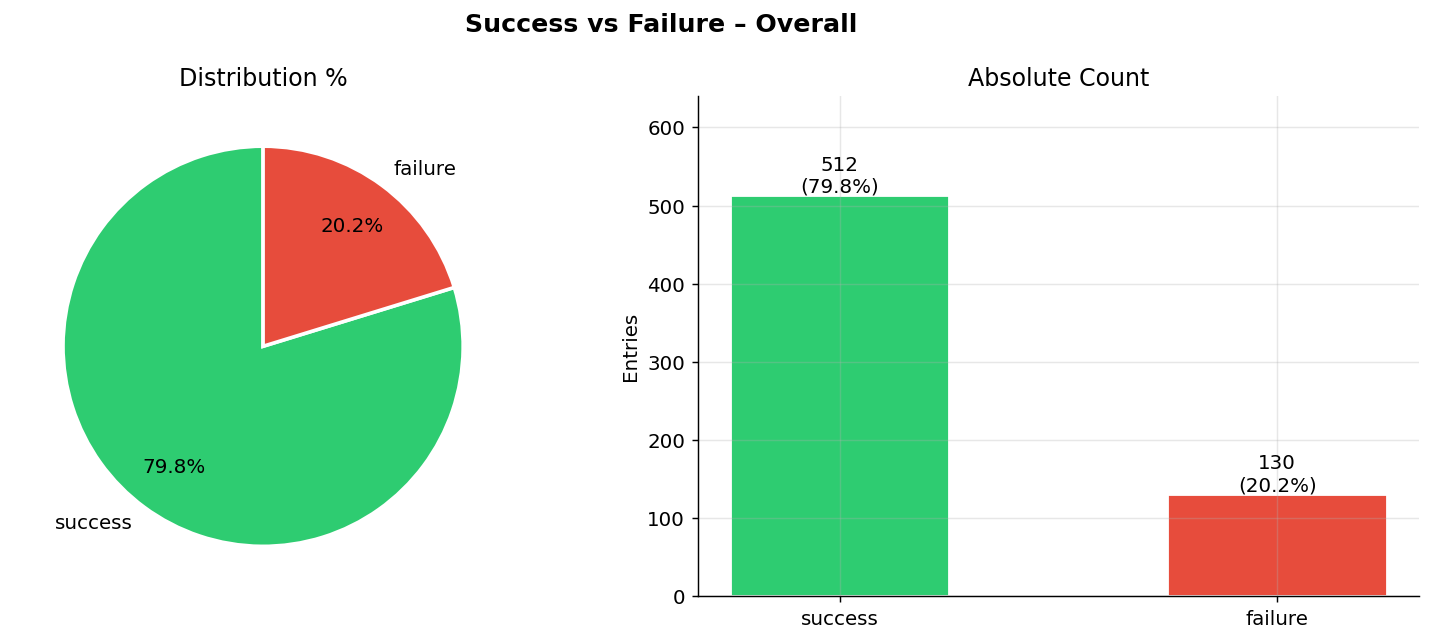

Total: 642 | Success: 512 | Failure: 130


In [4]:
overall = df_entry['status'].value_counts()
total   = overall.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Success vs Failure – Overall', fontsize=14, fontweight='bold')

colors = [PALETTE.get(s, '#95A5A6') for s in overall.index]
axes[0].pie(overall.values, labels=overall.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribution %')

bars = axes[1].bar(overall.index, overall.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, overall.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('Entries')
axes[1].set_title('Absolute Count')
axes[1].set_ylim(0, overall.max()*1.25)

plt.tight_layout(); plt.show()
print(f'Total: {total} | Success: {overall.get("success",0)} | Failure: {overall.get("failure",0)}')


### 2b. Success/Failure by **Model**

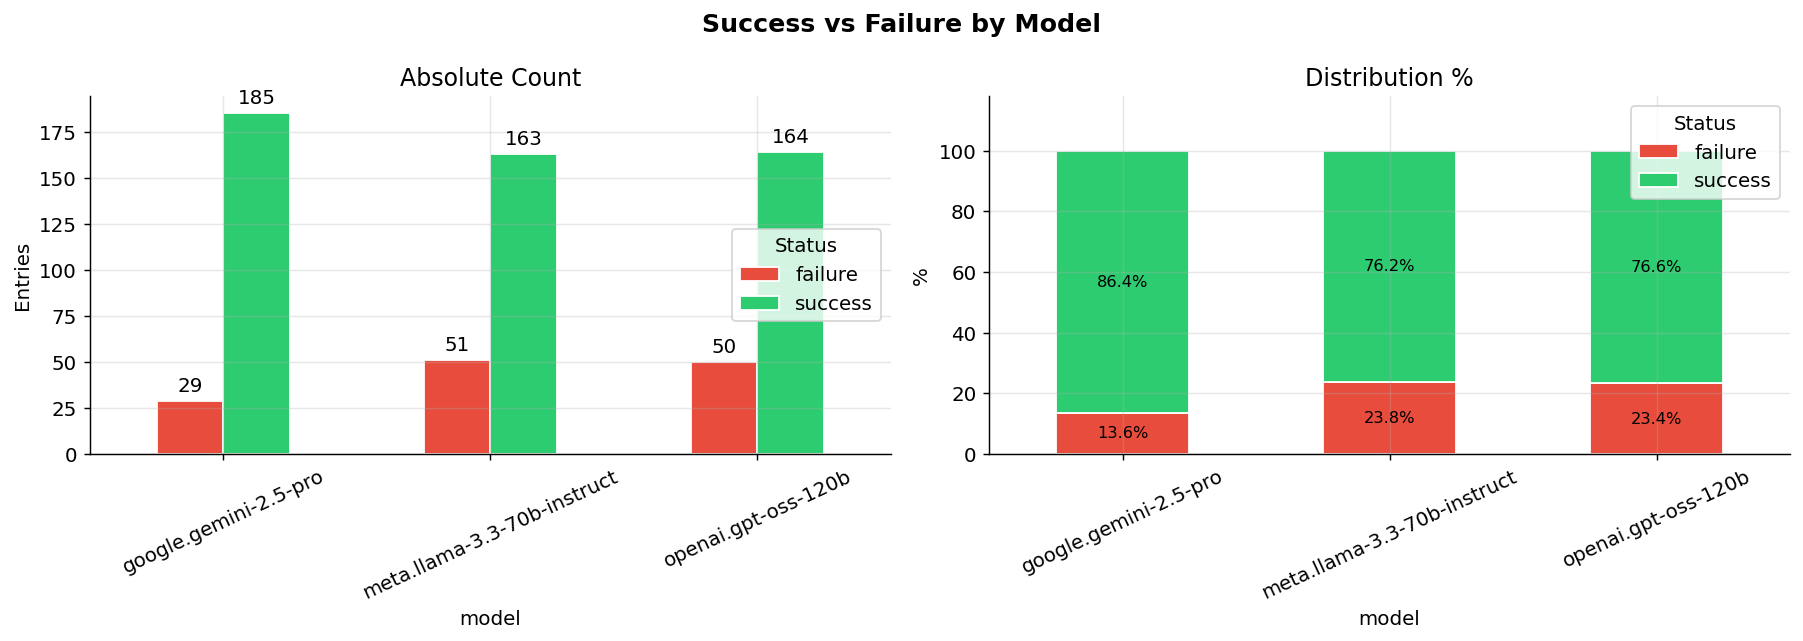

status                       failure  success
model                                        
google.gemini-2.5-pro           13.6     86.4
meta.llama-3.3-70b-instruct     23.8     76.2
openai.gpt-oss-120b             23.4     76.6


In [5]:
by_model = (df_entry.groupby(['model','status'])
            .size().unstack(fill_value=0))
by_model_pct = by_model.div(by_model.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Success vs Failure by Model', fontsize=14, fontweight='bold')

bar_cols = [PALETTE.get(s,'#95A5A6') for s in by_model.columns]
by_model.plot(kind='bar', ax=axes[0], color=bar_cols, edgecolor='white', rot=25)
axes[0].set_title('Absolute Count'); axes[0].set_ylabel('Entries')
axes[0].legend(title='Status')
for c in axes[0].containers: axes[0].bar_label(c, fmt='%d', padding=3)

by_model_pct.plot(kind='bar', stacked=True, ax=axes[1], color=bar_cols, edgecolor='white', rot=25)
axes[1].set_title('Distribution %'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 118); axes[1].legend(title='Status', loc='upper right')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)

plt.tight_layout(); plt.show()
print(by_model_pct.round(1))


### 2c. Success/Failure by Language

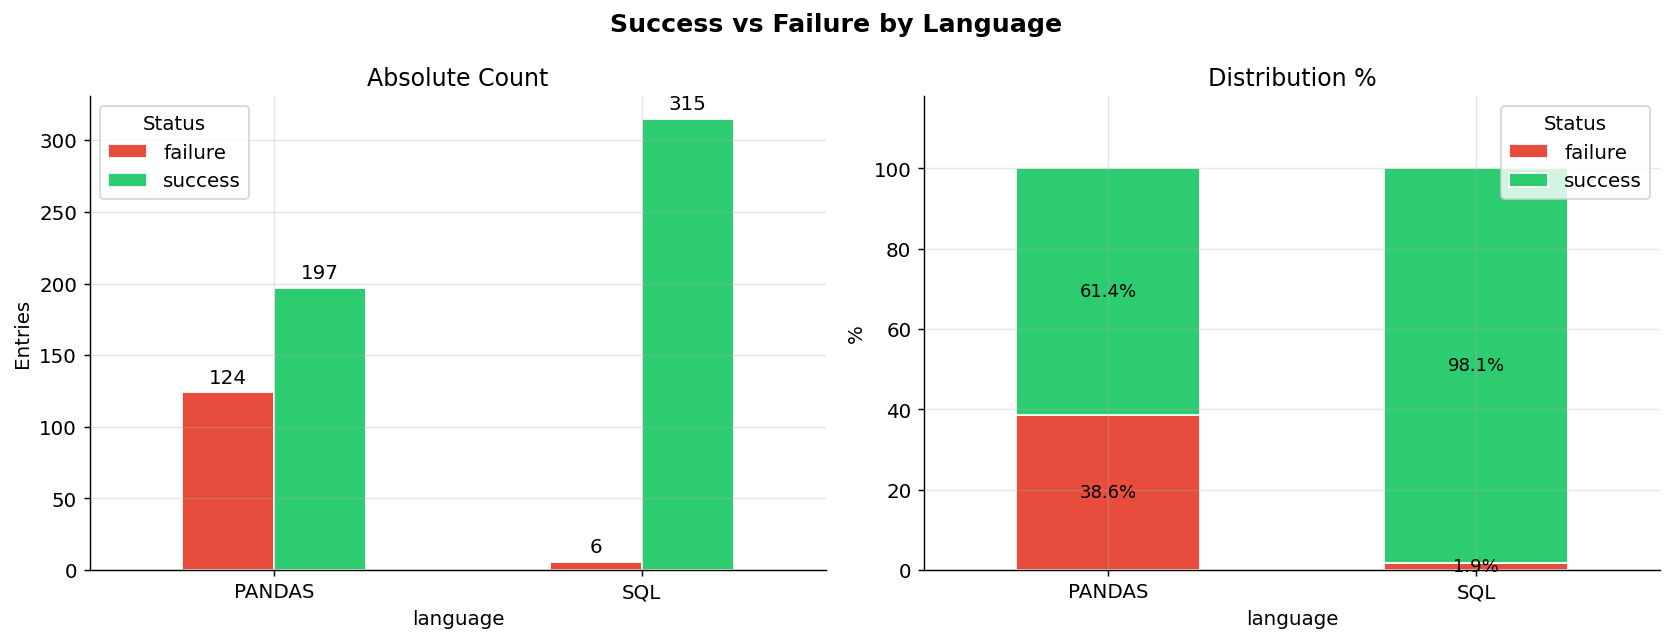

status    failure  success
language                  
PANDAS       38.6     61.4
SQL           1.9     98.1


In [6]:
by_lang = (df_entry.groupby(['language','status'])
           .size().unstack(fill_value=0))
by_lang_pct = by_lang.div(by_lang.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Success vs Failure by Language', fontsize=14, fontweight='bold')

bar_cols = [PALETTE.get(s,'#95A5A6') for s in by_lang.columns]
by_lang.plot(kind='bar', ax=axes[0], color=bar_cols, edgecolor='white', rot=0)
axes[0].set_title('Absolute Count'); axes[0].set_ylabel('Entries')
axes[0].legend(title='Status')
for c in axes[0].containers: axes[0].bar_label(c, fmt='%d', padding=3)

by_lang_pct.plot(kind='bar', stacked=True, ax=axes[1], color=bar_cols, edgecolor='white', rot=0)
axes[1].set_title('Distribution %'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 118); axes[1].legend(title='Status', loc='upper right')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=10)

plt.tight_layout(); plt.show()
print(by_lang_pct.round(1))


### 2d. Success/Failure by Difficulty

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\3223385276.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_diff = (df_entry_d.groupby(['difficulty','status'])


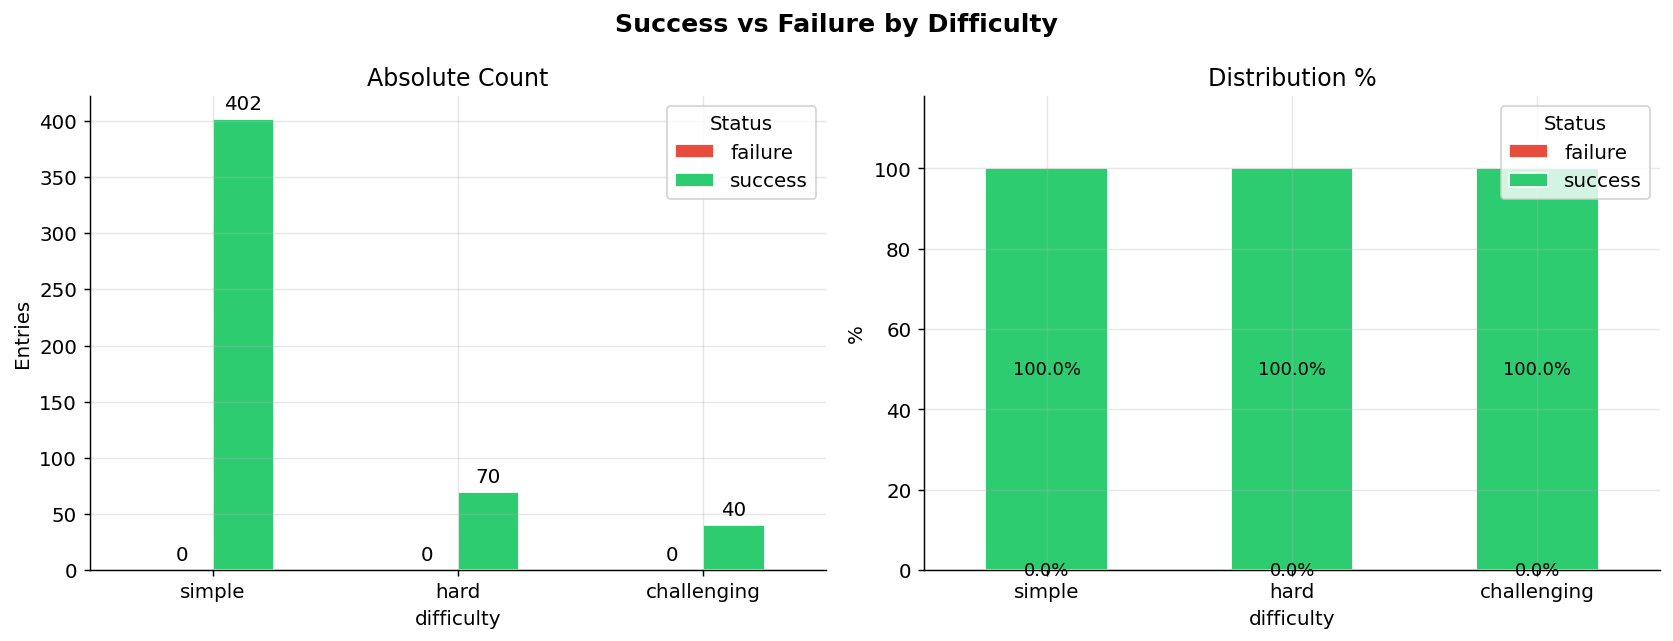

status       failure  success
difficulty                   
simple           0.0    100.0
hard             0.0    100.0
challenging      0.0    100.0


In [7]:
first_q = df_query.groupby(['model','language','entry_id'])['difficulty'].first().reset_index()
df_entry_d = df_entry.merge(first_q, on=['model','language','entry_id'], how='left')

by_diff = (df_entry_d.groupby(['difficulty','status'])
           .size().unstack(fill_value=0).reindex(DIFF_ORDER))
by_diff_pct = by_diff.div(by_diff.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Success vs Failure by Difficulty', fontsize=14, fontweight='bold')

bar_cols = [PALETTE.get(s,'#95A5A6') for s in by_diff.columns]
by_diff.plot(kind='bar', ax=axes[0], color=bar_cols, edgecolor='white', rot=0)
axes[0].set_title('Absolute Count'); axes[0].set_ylabel('Entries')
axes[0].legend(title='Status')
for c in axes[0].containers: axes[0].bar_label(c, fmt='%d', padding=3)

by_diff_pct.plot(kind='bar', stacked=True, ax=axes[1], color=bar_cols, edgecolor='white', rot=0)
axes[1].set_title('Distribution %'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 118); axes[1].legend(title='Status', loc='upper right')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontsize=10)

plt.tight_layout(); plt.show()
print(by_diff_pct.round(1))


---
## 3. Response Production

*How many queries that executed successfully also produced a non-null response?*

### 3a. Overall Response Rate

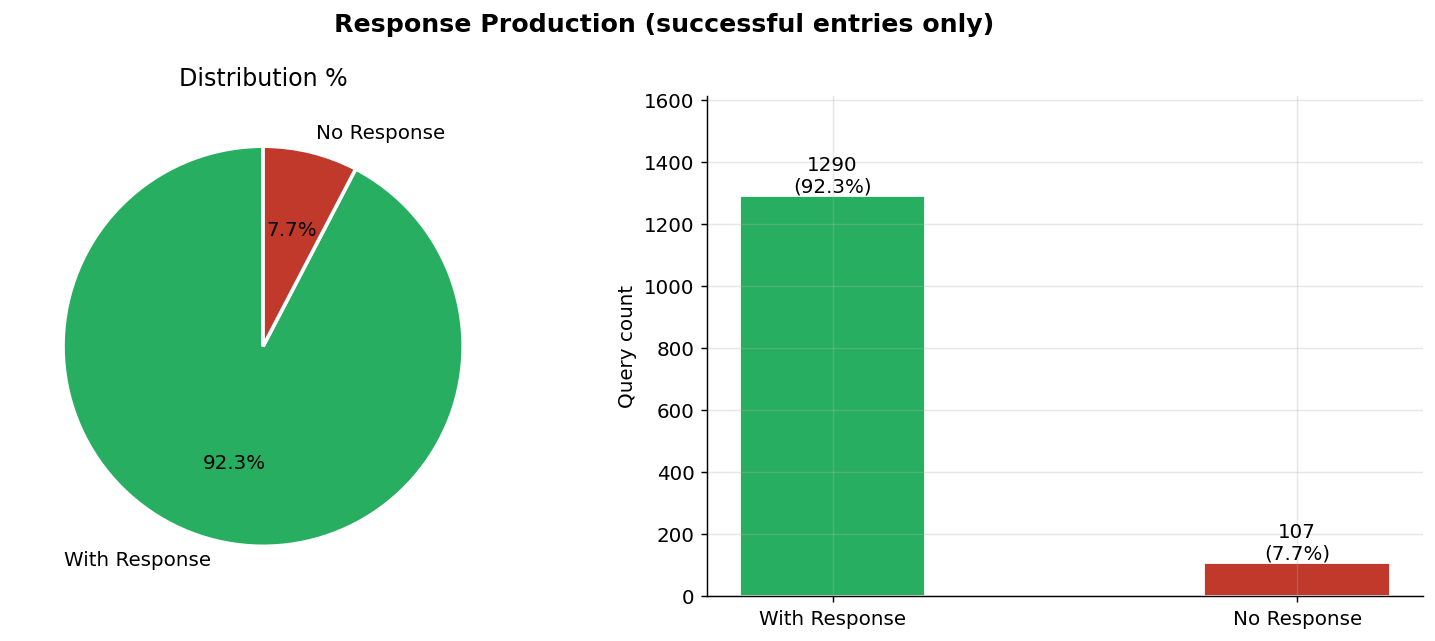

Response rate: 92.3%


In [8]:
resp_overall = df_ok['has_response'].value_counts().rename({True:'With Response', False:'No Response'})
total_ok = resp_overall.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Response Production (successful entries only)', fontsize=14, fontweight='bold')

colors = [PALETTE['with_response'], PALETTE['without_response']]
axes[0].pie(resp_overall.values, labels=resp_overall.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribution %')

bars = axes[1].bar(resp_overall.index, resp_overall.values, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, resp_overall.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val}\n({val/total_ok*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('Query count'); axes[1].set_ylim(0, resp_overall.max()*1.25)

plt.tight_layout(); plt.show()
print(f'Response rate: {df_ok["has_response"].mean()*100:.1f}%')


### 3b. Response Rate by Model

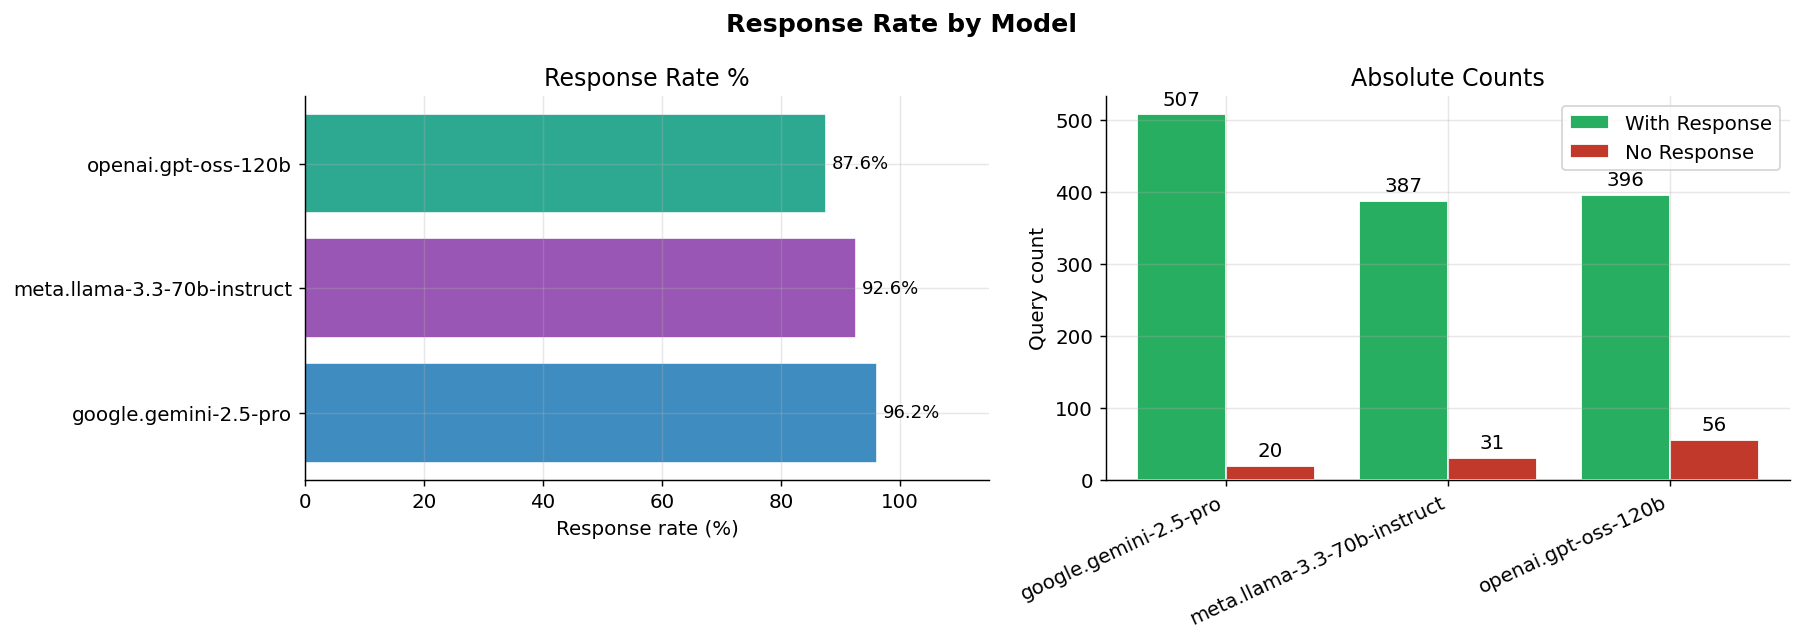

                             with_resp  total        pct
model                                                   
google.gemini-2.5-pro              507    527  96.204934
meta.llama-3.3-70b-instruct        387    418  92.583732
openai.gpt-oss-120b                396    452  87.610619


In [9]:
resp_by_model = (df_ok.groupby('model')['has_response']
                 .agg(['sum','count']).rename(columns={'sum':'with_resp','count':'total'}))
resp_by_model['pct'] = resp_by_model['with_resp'] / resp_by_model['total'] * 100
resp_by_model = resp_by_model.sort_values('pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Response Rate by Model', fontsize=14, fontweight='bold')

m_colors = [MODEL_PALETTE.get(m, '#95A5A6') for m in resp_by_model.index]

axes[0].barh(resp_by_model.index, resp_by_model['pct'], color=m_colors, edgecolor='white', alpha=0.9)
axes[0].set_xlabel('Response rate (%)'); axes[0].set_title('Response Rate %')
axes[0].set_xlim(0, 115)
for i,(v,) in enumerate(zip(resp_by_model['pct'])):
    axes[0].text(v+1, i, f'{v:.1f}%', va='center', fontsize=10)

x  = np.arange(len(resp_by_model))
w  = 0.4
b1 = axes[1].bar(x-w/2, resp_by_model['with_resp'], width=w, label='With Response',
                  color=PALETTE['with_response'], edgecolor='white')
b2 = axes[1].bar(x+w/2, resp_by_model['total']-resp_by_model['with_resp'], width=w,
                  label='No Response', color=PALETTE['without_response'], edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(resp_by_model.index, rotation=25, ha='right')
axes[1].set_ylabel('Query count'); axes[1].set_title('Absolute Counts')
axes[1].legend()
for bars in [b1, b2]: axes[1].bar_label(bars, fmt='%d', padding=3)

plt.tight_layout(); plt.show()
print(resp_by_model)


### 3c. Response Rate by Model × Language

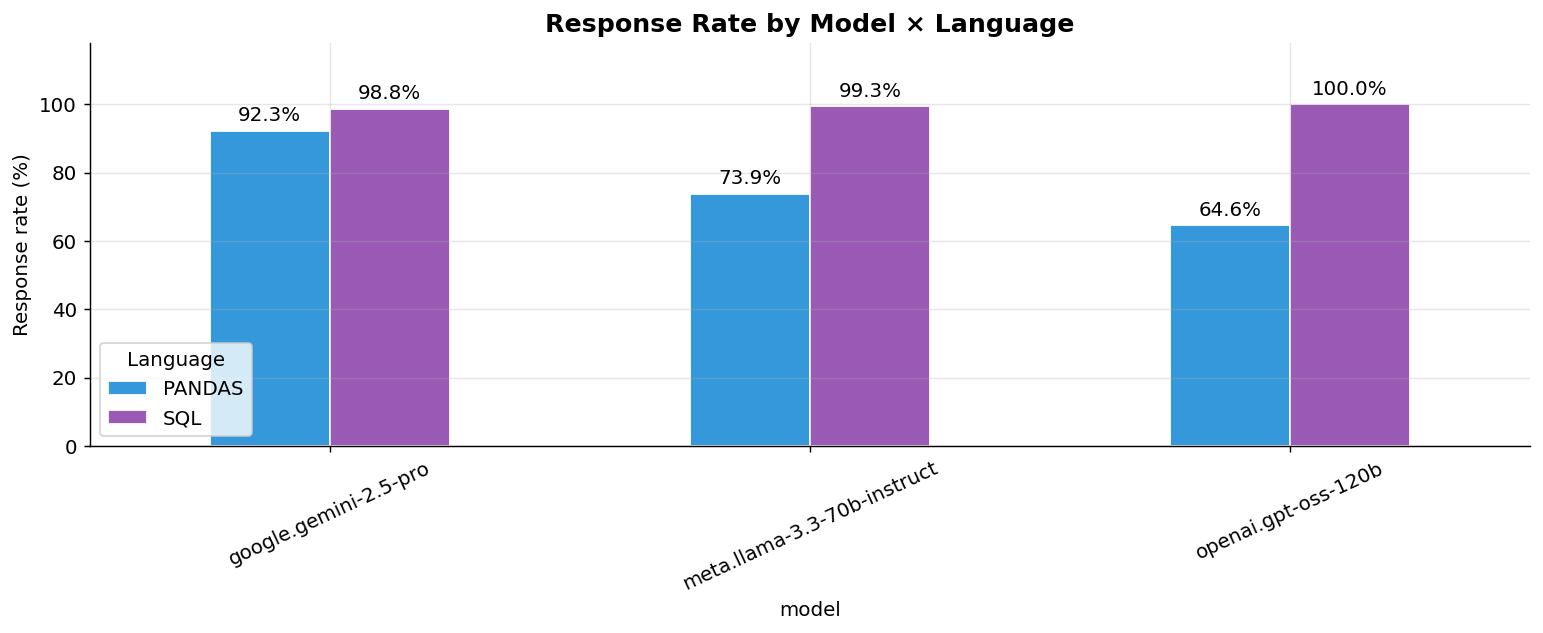

In [10]:
resp_ml = (df_ok.groupby(['model','language'])['has_response']
           .agg(['sum','count']).rename(columns={'sum':'with_resp','count':'total'}).reset_index())
resp_ml['pct'] = resp_ml['with_resp'] / resp_ml['total'] * 100

pivot_resp = resp_ml.pivot(index='model', columns='language', values='pct')

ax = pivot_resp.plot(kind='bar', figsize=(12, 5), edgecolor='white',
                     color=[PALETTE['PANDAS'], PALETTE['SQL']], rot=25)
ax.set_title('Response Rate by Model × Language', fontsize=14, fontweight='bold')
ax.set_ylabel('Response rate (%)'); ax.set_ylim(0, 118)
ax.legend(title='Language')
for c in ax.containers: ax.bar_label(c, fmt='%.1f%%', padding=3)
plt.tight_layout(); plt.show()


### 3d. Response Rate by Difficulty

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\954580141.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resp_diff = (df_ok.groupby(['model','difficulty'])['has_response']


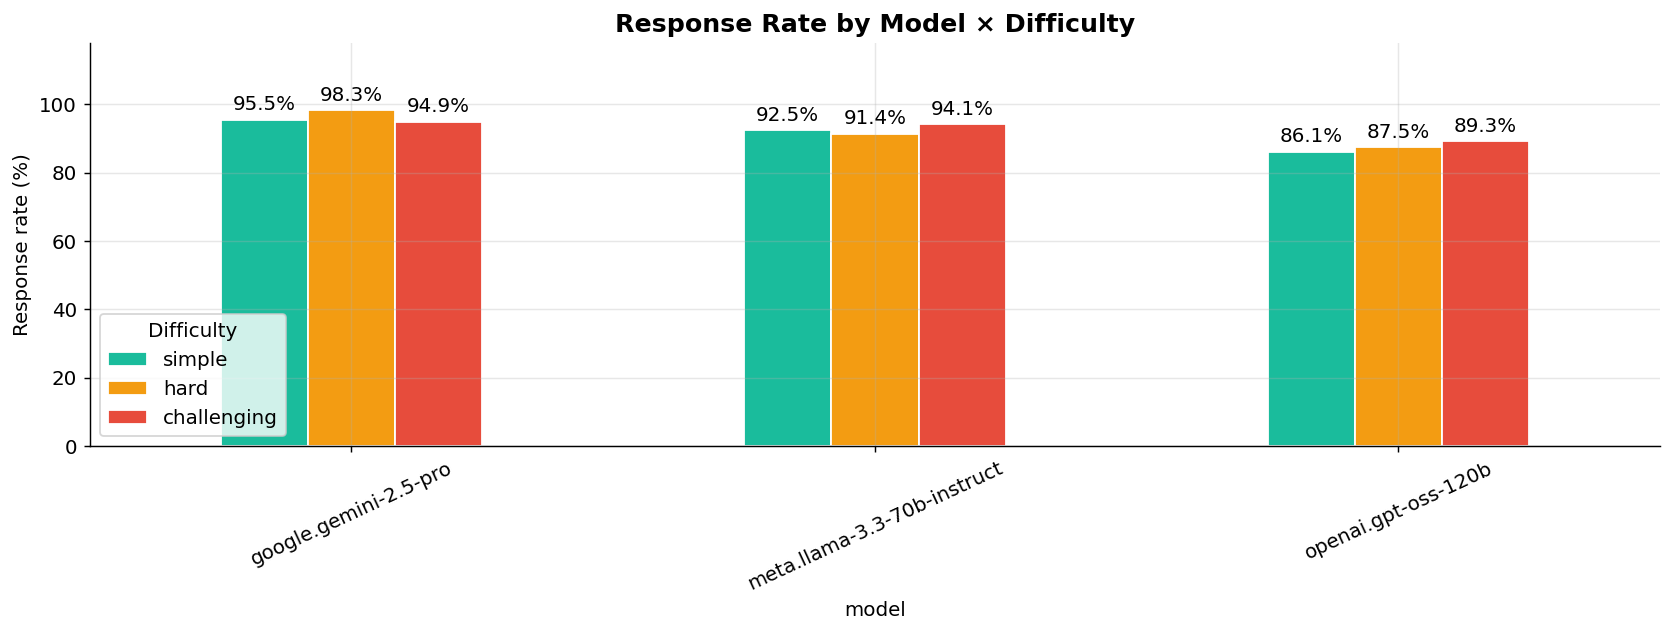

In [11]:
resp_diff = (df_ok.groupby(['model','difficulty'])['has_response']
            .mean().mul(100).reset_index().rename(columns={'has_response':'pct'}))

pivot_rd = resp_diff.pivot(index='model', columns='difficulty', values='pct').reindex(columns=DIFF_ORDER)

ax = pivot_rd.plot(kind='bar', figsize=(13, 5), edgecolor='white',
                   color=[PALETTE[d] for d in DIFF_ORDER], rot=25)
ax.set_title('Response Rate by Model × Difficulty', fontsize=14, fontweight='bold')
ax.set_ylabel('Response rate (%)'); ax.set_ylim(0, 118)
ax.legend(title='Difficulty')
for c in ax.containers: ax.bar_label(c, fmt='%.1f%%', padding=3)
plt.tight_layout(); plt.show()


---
## 4. Token Consumption

*Only entries with `status == 'success'` and non-zero token counts are included.*

### 4a. Total Token Budget by Model

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\1787553308.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tok_model.index, rotation=25, ha='right')


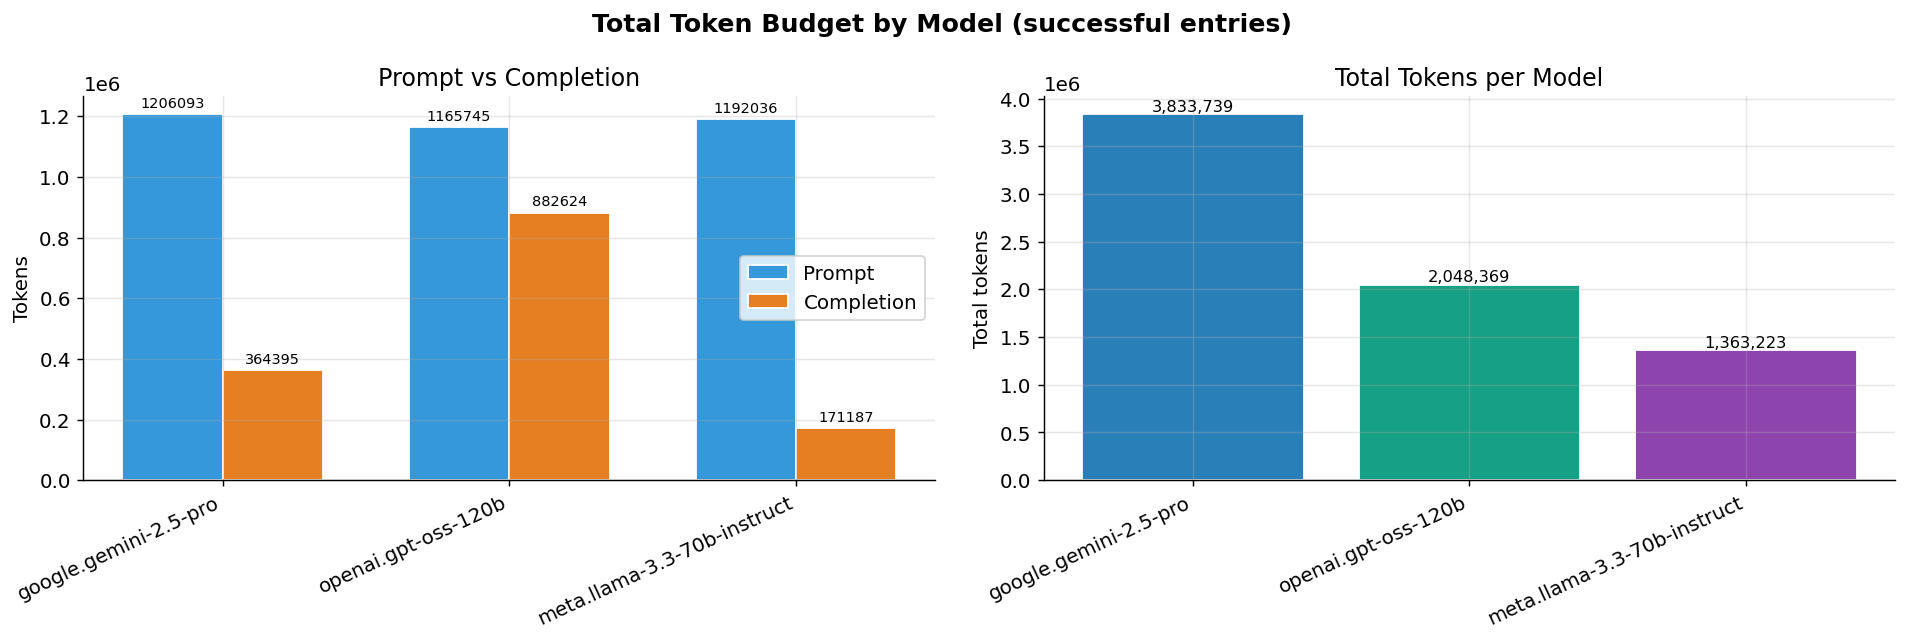

                             prompt_tokens  completion_tokens  total_tokens
model                                                                      
google.gemini-2.5-pro              1206093             364395       3833739
openai.gpt-oss-120b                1165745             882624       2048369
meta.llama-3.3-70b-instruct        1192036             171187       1363223


In [12]:
df_tok = df_entry[(df_entry['status']=='success') & (df_entry['total_tokens']>0)].copy()

tok_model = df_tok.groupby('model')[['prompt_tokens','completion_tokens','total_tokens']].sum()
tok_model = tok_model.sort_values('total_tokens', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Total Token Budget by Model (successful entries)', fontsize=14, fontweight='bold')

x = np.arange(len(tok_model)); w = 0.35
m_colors = [MODEL_PALETTE.get(m,'#95A5A6') for m in tok_model.index]

b1 = axes[0].bar(x-w/2, tok_model['prompt_tokens'], width=w, label='Prompt', color='#3498DB', edgecolor='white')
b2 = axes[0].bar(x+w/2, tok_model['completion_tokens'], width=w, label='Completion', color='#E67E22', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(tok_model.index, rotation=25, ha='right')
axes[0].set_ylabel('Tokens'); axes[0].set_title('Prompt vs Completion')
axes[0].legend()
for bars in [b1,b2]: axes[0].bar_label(bars, fmt='%d', padding=2, fontsize=8)

bars2 = axes[1].bar(tok_model.index, tok_model['total_tokens'], color=m_colors, edgecolor='white')
for bar, val in zip(bars2, tok_model['total_tokens']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9)
axes[1].set_xticklabels(tok_model.index, rotation=25, ha='right')
axes[1].set_ylabel('Total tokens'); axes[1].set_title('Total Tokens per Model')

plt.tight_layout(); plt.show()
print(tok_model)


### 4b. Tokens per Entry – Distribution

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\802096094.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(bp_data, labels=tok_model.index, patch_artist=True,


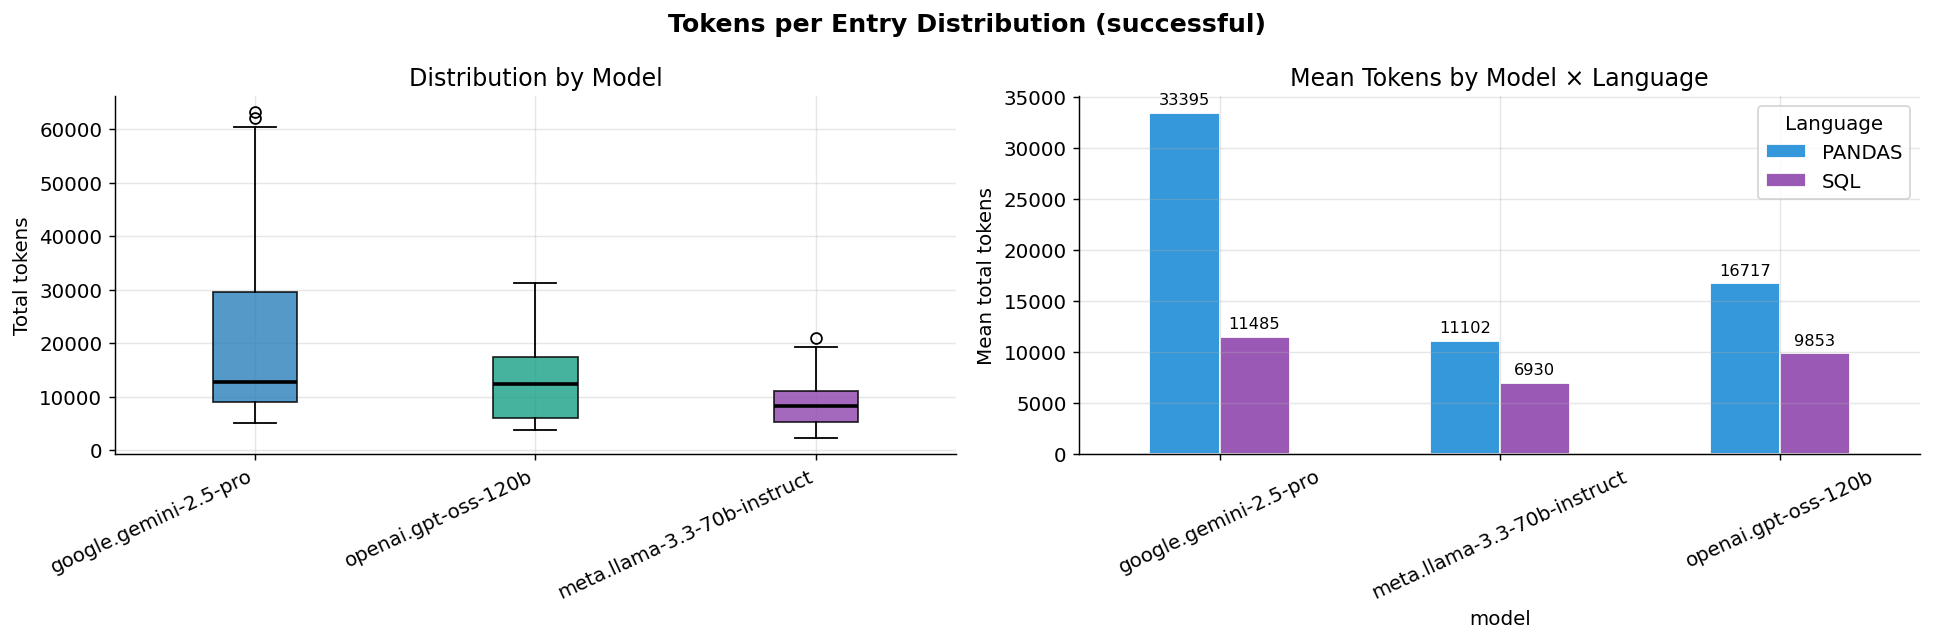

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Tokens per Entry Distribution (successful)', fontsize=14, fontweight='bold')

# Boxplot by model
bp_data = [df_tok[df_tok['model']==m]['total_tokens'].values for m in tok_model.index]
bp = axes[0].boxplot(bp_data, labels=tok_model.index, patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
for patch, m in zip(bp['boxes'], tok_model.index):
    patch.set_facecolor(MODEL_PALETTE.get(m,'#95A5A6')); patch.set_alpha(0.8)
axes[0].set_ylabel('Total tokens'); axes[0].set_title('Distribution by Model')
axes[0].set_xticklabels(tok_model.index, rotation=25, ha='right')

# Mean tokens: model × language
tok_ml = df_tok.groupby(['model','language'])['total_tokens'].mean().reset_index()
pivot_tok = tok_ml.pivot(index='model', columns='language', values='total_tokens')
pivot_tok.plot(kind='bar', ax=axes[1], color=[PALETTE['PANDAS'],PALETTE['SQL']], edgecolor='white', rot=25)
axes[1].set_ylabel('Mean total tokens'); axes[1].set_title('Mean Tokens by Model × Language')
axes[1].legend(title='Language')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.0f', padding=3, fontsize=9)

plt.tight_layout(); plt.show()


### 4c. Prompt/Completion Ratio by Model

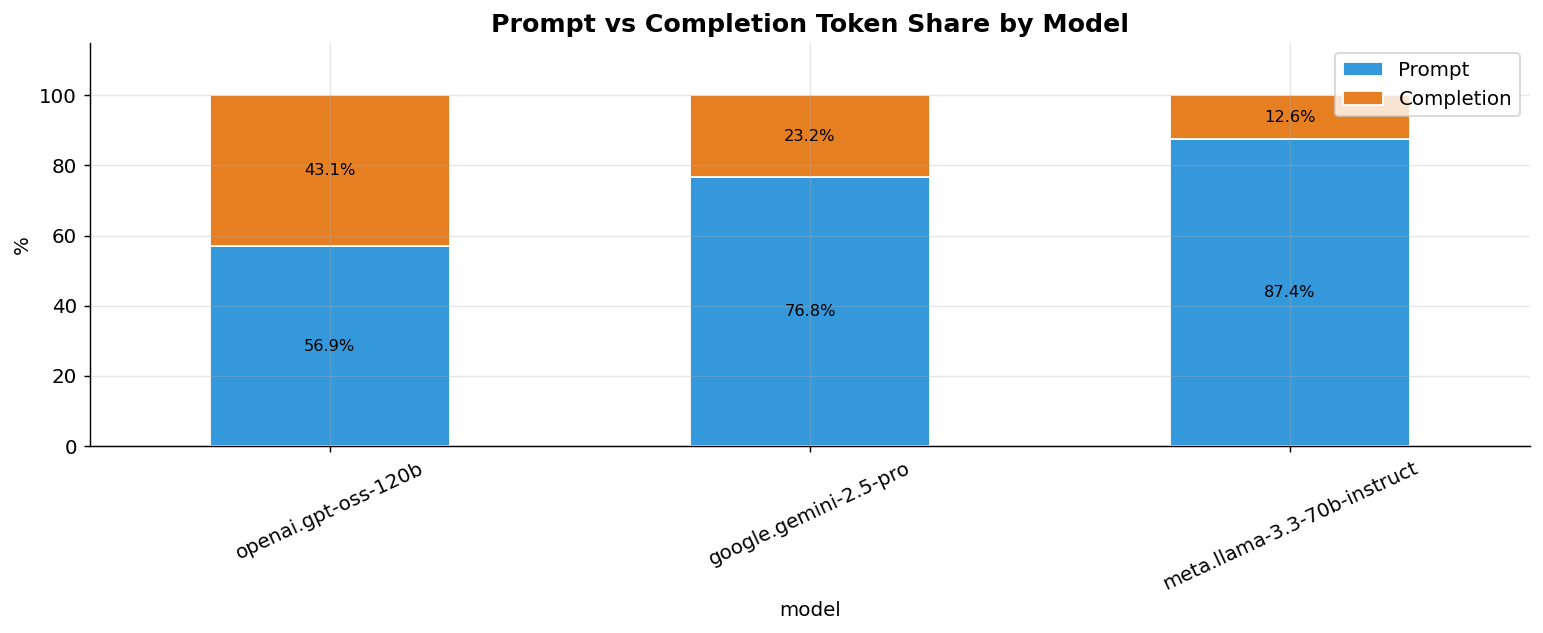

                             prompt_tokens  completion_tokens  p_ratio  \
model                                                                    
openai.gpt-oss-120b                 7108.2             5381.9     56.9   
google.gemini-2.5-pro               6519.4             1969.7     76.8   
meta.llama-3.3-70b-instruct         7313.1             1050.2     87.4   

                             c_ratio  
model                                 
openai.gpt-oss-120b             43.1  
google.gemini-2.5-pro           23.2  
meta.llama-3.3-70b-instruct     12.6  


In [14]:
tok_ratio = df_tok.groupby('model')[['prompt_tokens','completion_tokens']].mean()
tok_ratio['p_ratio'] = tok_ratio['prompt_tokens'] / (tok_ratio['prompt_tokens']+tok_ratio['completion_tokens']) * 100
tok_ratio['c_ratio'] = 100 - tok_ratio['p_ratio']
tok_ratio = tok_ratio.sort_values('c_ratio', ascending=False)

ax = tok_ratio[['p_ratio','c_ratio']].plot(kind='bar', stacked=True, figsize=(12, 5),
                                              color=['#3498DB','#E67E22'], edgecolor='white', rot=25)
ax.set_title('Prompt vs Completion Token Share by Model', fontsize=14, fontweight='bold')
ax.set_ylabel('%'); ax.set_ylim(0, 115)
ax.legend(['Prompt','Completion'])
for c in ax.containers: ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout(); plt.show()
print(tok_ratio[['prompt_tokens','completion_tokens','p_ratio','c_ratio']].round(1))


### 4d. Token Efficiency: Tokens per Successful Response

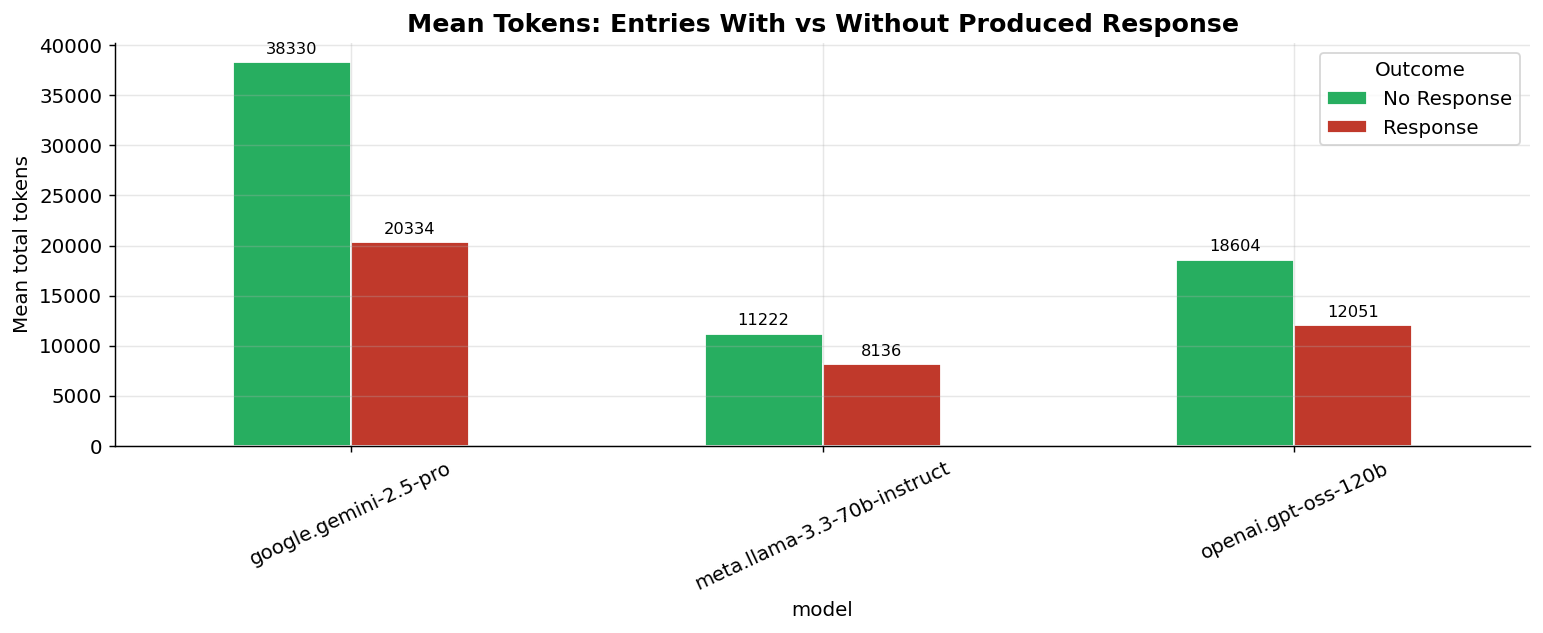

In [15]:
# tokens consumed per entry that actually produced a response
df_tok_resp = df_entry[
    (df_entry['status']=='success') & (df_entry['total_tokens']>0)
].copy()
# merge with response flag aggregated at entry level
resp_flag = df_ok.groupby(['model','language','entry_id'])['has_response'].any().reset_index()
df_tok_resp = df_tok_resp.merge(resp_flag, on=['model','language','entry_id'], how='left')

eff = (df_tok_resp.groupby(['model','has_response'])['total_tokens']
       .mean().reset_index().rename(columns={'has_response':'produced_response','total_tokens':'mean_tokens'}))
eff['produced_response'] = eff['produced_response'].map({True:'Response',False:'No Response'})

pivot_eff = eff.pivot(index='model', columns='produced_response', values='mean_tokens')
ax = pivot_eff.plot(kind='bar', figsize=(12, 5),
                    color=[PALETTE['with_response'],PALETTE['without_response']], edgecolor='white', rot=25)
ax.set_title('Mean Tokens: Entries With vs Without Produced Response', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean total tokens'); ax.legend(title='Outcome')
for c in ax.containers: ax.bar_label(c, fmt='%.0f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()


---
## 5. Generation Time

*Wall-clock seconds per entry.*

### 5a. Distribution by Model

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\3183153218.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(bp_data, labels=gt_order, patch_artist=True,


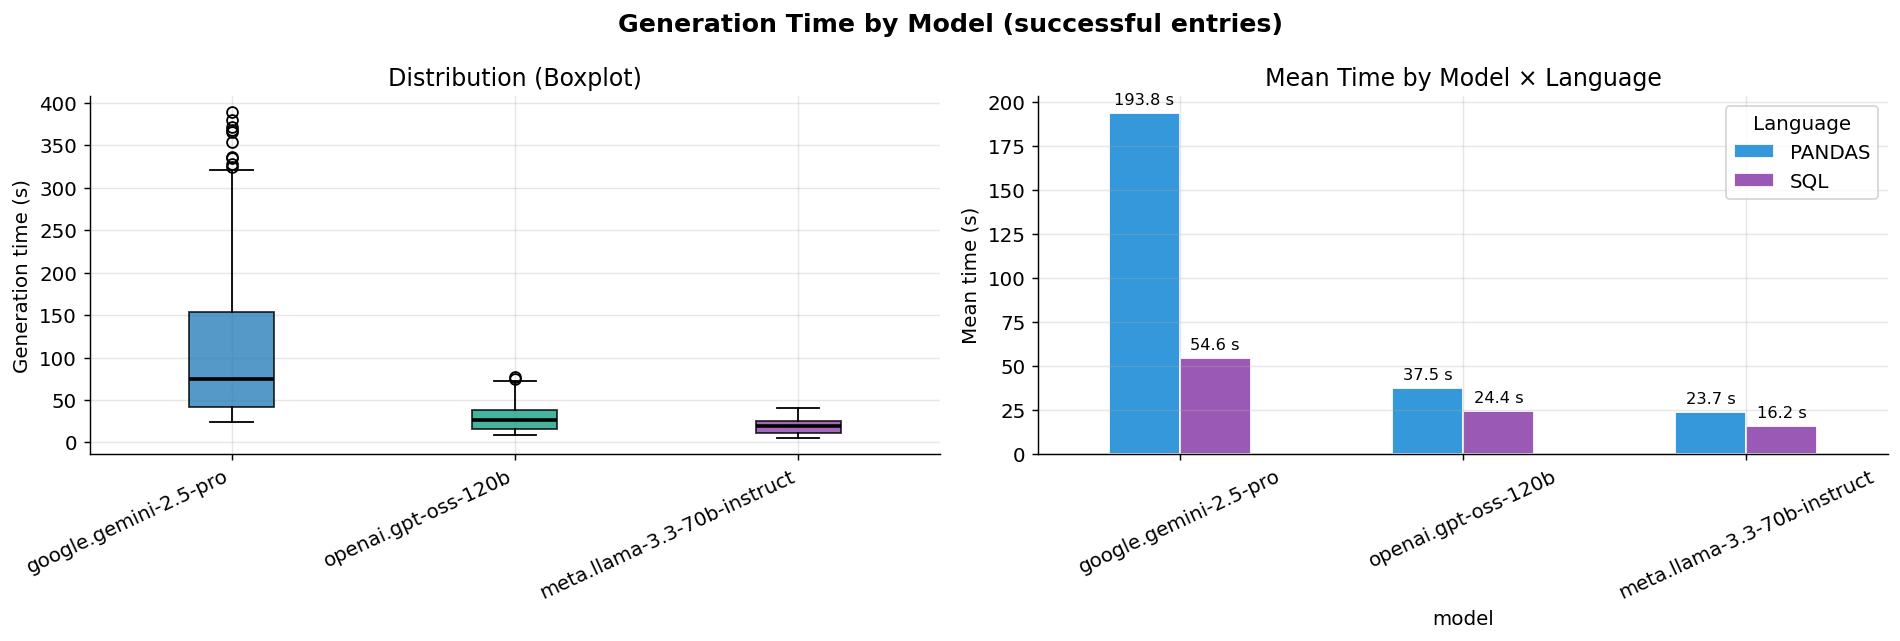

                               mean  median    min     max
model                                                     
google.gemini-2.5-pro        113.29   74.41  24.03  388.63
meta.llama-3.3-70b-instruct   18.76   19.46   5.55   40.36
openai.gpt-oss-120b           29.43   26.50   8.14   77.23


In [16]:
df_gt = df_entry[(df_entry['status']=='success') & df_entry['generation_time'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Generation Time by Model (successful entries)', fontsize=14, fontweight='bold')

gt_order = df_gt.groupby('model')['generation_time'].median().sort_values(ascending=False).index.tolist()
bp_data  = [df_gt[df_gt['model']==m]['generation_time'].values for m in gt_order]
bp = axes[0].boxplot(bp_data, labels=gt_order, patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
for patch, m in zip(bp['boxes'], gt_order):
    patch.set_facecolor(MODEL_PALETTE.get(m,'#95A5A6')); patch.set_alpha(0.8)
axes[0].set_ylabel('Generation time (s)'); axes[0].set_title('Distribution (Boxplot)')
axes[0].set_xticklabels(gt_order, rotation=25, ha='right')

# Mean gen time by model and language
gt_ml = df_gt.groupby(['model','language'])['generation_time'].mean().reset_index()
pivot_gt = gt_ml.pivot(index='model', columns='language', values='generation_time').reindex(gt_order)
pivot_gt.plot(kind='bar', ax=axes[1], color=[PALETTE['PANDAS'],PALETTE['SQL']], edgecolor='white', rot=25)
axes[1].set_ylabel('Mean time (s)'); axes[1].set_title('Mean Time by Model × Language')
axes[1].legend(title='Language')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.1f s', padding=3, fontsize=9)

plt.tight_layout(); plt.show()
print(df_gt.groupby('model')['generation_time'].agg(['mean','median','min','max']).round(2))


### 5b. Generation Time vs Token Count (Scatter)

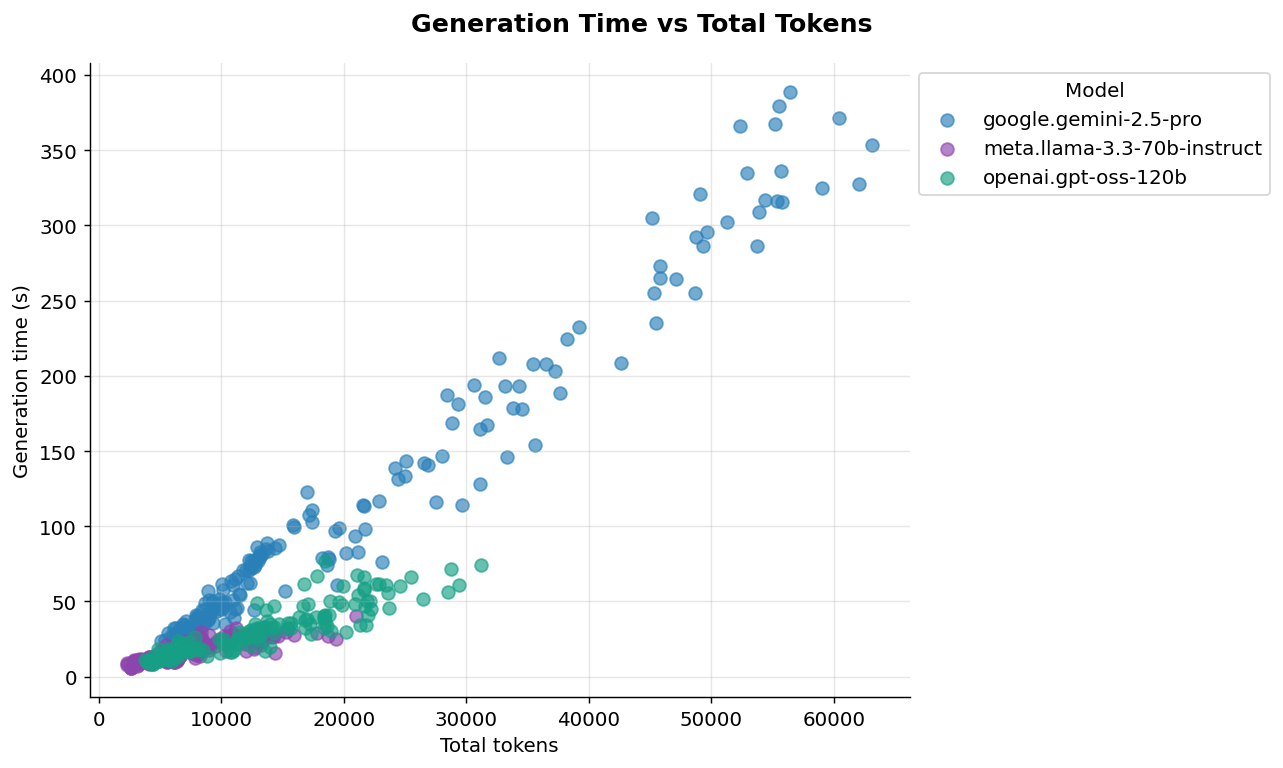

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Generation Time vs Total Tokens', fontsize=14, fontweight='bold')

for m in models:
    sub = df_gt[df_gt['model']==m]
    ax.scatter(sub['total_tokens'], sub['generation_time'],
               label=m, color=MODEL_PALETTE.get(m), alpha=0.65, s=50)

ax.set_xlabel('Total tokens'); ax.set_ylabel('Generation time (s)')
ax.legend(title='Model', bbox_to_anchor=(1,1))
plt.tight_layout(); plt.show()


---
## 6. Queries per Difficulty by Model

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\3995001506.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_diff = (df_ok.groupby(['model','difficulty'])


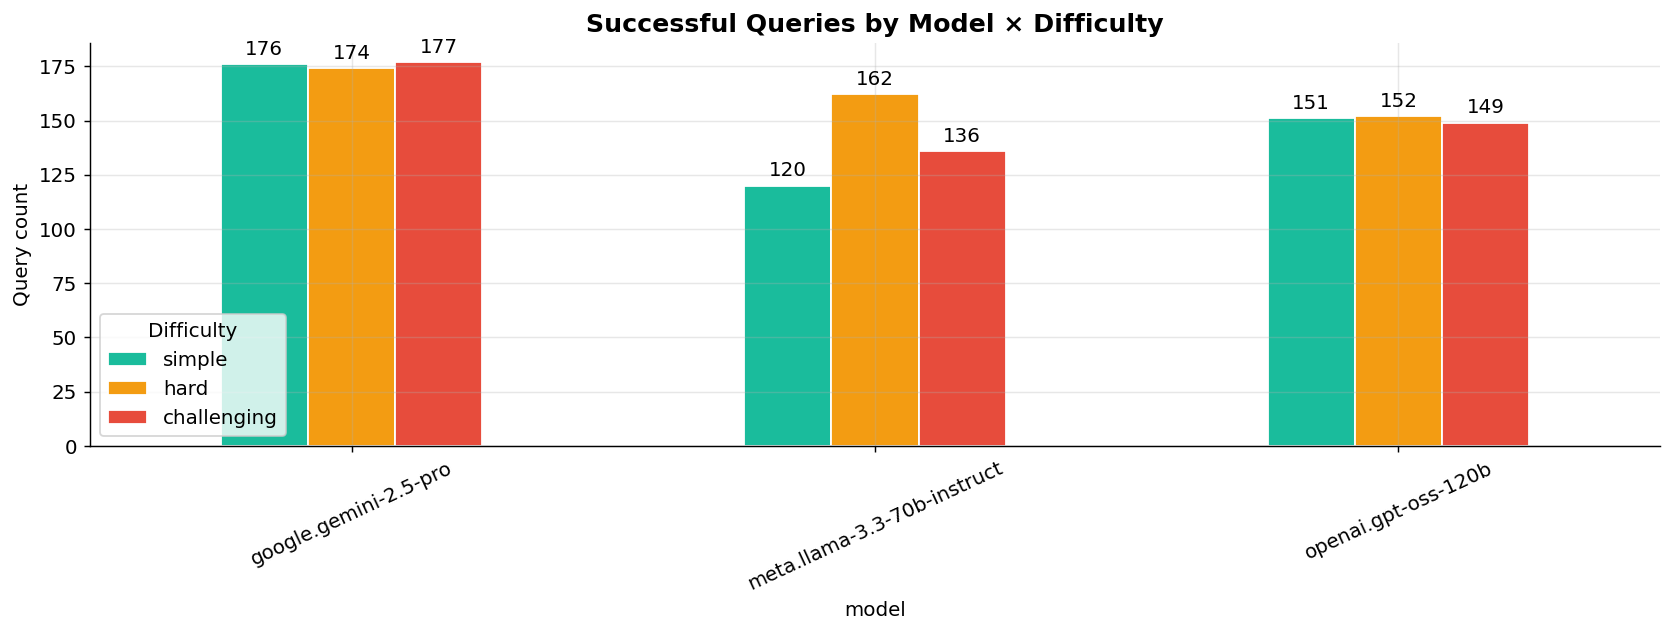

difficulty                   simple  hard  challenging
model                                                 
google.gemini-2.5-pro           176   174          177
meta.llama-3.3-70b-instruct     120   162          136
openai.gpt-oss-120b             151   152          149


In [18]:
pivot_diff = (df_ok.groupby(['model','difficulty'])
              .size().reset_index(name='count')
              .pivot(index='model', columns='difficulty', values='count').fillna(0)
              .reindex(columns=DIFF_ORDER))

ax = pivot_diff.plot(kind='bar', figsize=(13, 5),
                     color=[PALETTE[d] for d in DIFF_ORDER], edgecolor='white', rot=25)
ax.set_title('Successful Queries by Model × Difficulty', fontsize=14, fontweight='bold')
ax.set_ylabel('Query count'); ax.legend(title='Difficulty')
for c in ax.containers: ax.bar_label(c, fmt='%d', padding=3)
plt.tight_layout(); plt.show()
print(pivot_diff.astype(int))


---
## 7. Table Coverage

C:\Users\39377\AppData\Local\Temp\ipykernel_10964\2057976983.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = (df_ok.groupby(['difficulty','n_tables']).size().unstack(fill_value=0).reindex(DIFF_ORDER))
C:\Users\39377\AppData\Local\Temp\ipykernel_10964\2057976983.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=DIFF_ORDER, patch_artist=True,
C:\Users\39377\AppData\Local\Temp\ipykernel_10964\2057976983.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence

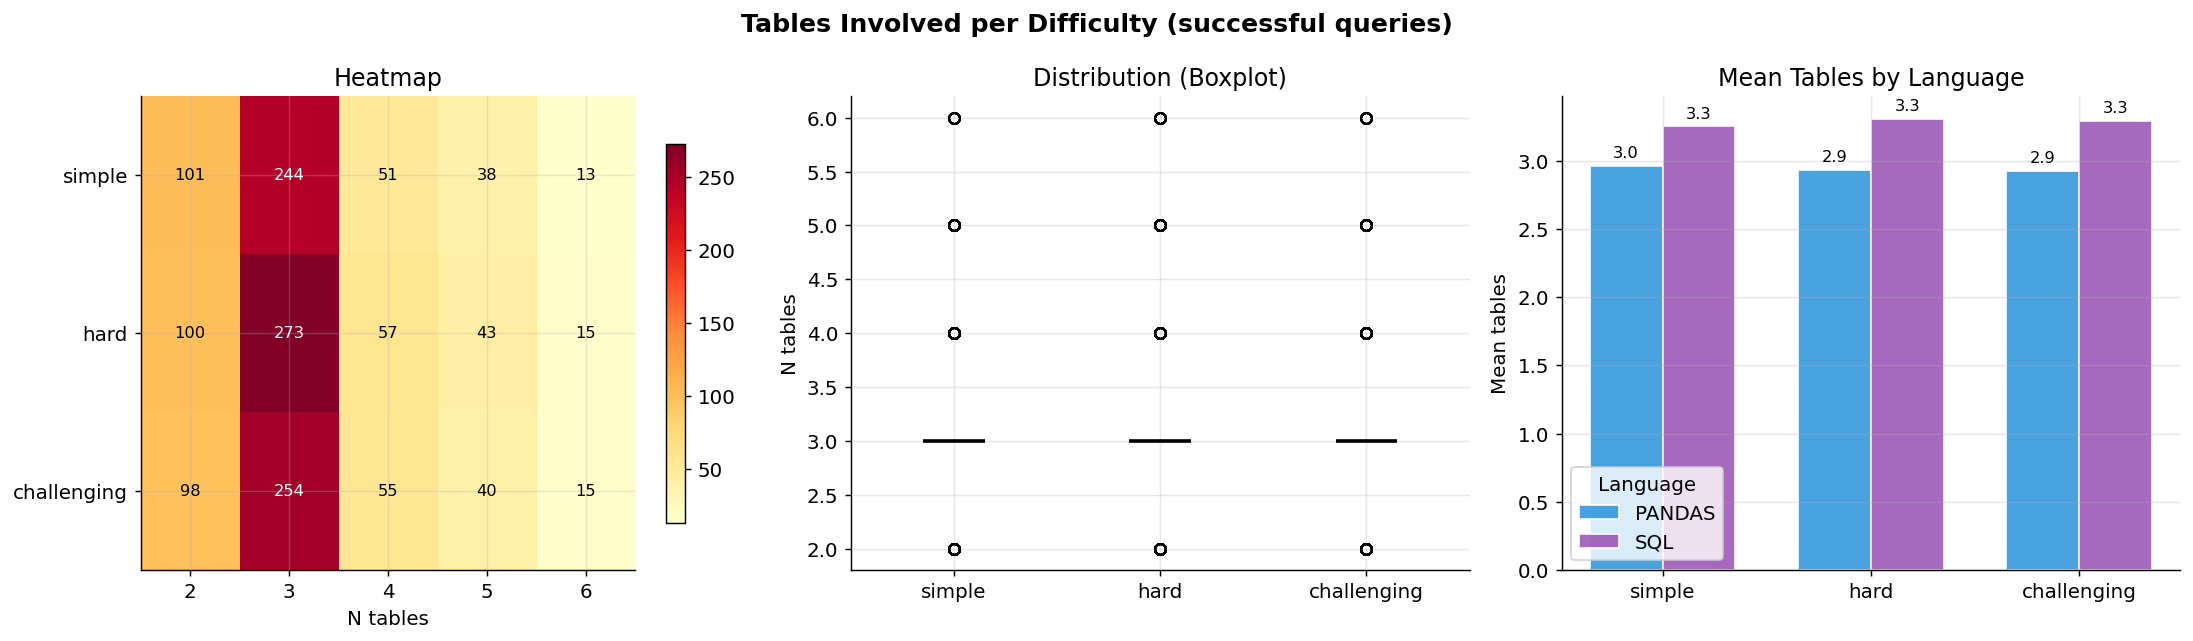

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Tables Involved per Difficulty (successful queries)', fontsize=14, fontweight='bold')

heat = (df_ok.groupby(['difficulty','n_tables']).size().unstack(fill_value=0).reindex(DIFF_ORDER))
im = axes[0].imshow(heat.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(heat.columns))); axes[0].set_xticklabels(heat.columns)
axes[0].set_yticks(range(len(heat.index))); axes[0].set_yticklabels(heat.index)
axes[0].set_xlabel('N tables'); axes[0].set_title('Heatmap')
plt.colorbar(im, ax=axes[0], shrink=0.8)
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        v = heat.values[i,j]
        if v > 0:
            axes[0].text(j,i,str(v),ha='center',va='center',fontsize=9,
                         color='white' if v>heat.values.max()*0.6 else 'black')

bp_data = [df_ok[df_ok['difficulty']==d]['n_tables'].values for d in DIFF_ORDER]
bp = axes[1].boxplot(bp_data, labels=DIFF_ORDER, patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
for patch, d in zip(bp['boxes'], DIFF_ORDER):
    patch.set_facecolor(PALETTE.get(d)); patch.set_alpha(0.8)
axes[1].set_ylabel('N tables'); axes[1].set_title('Distribution (Boxplot)')

avg = (df_ok.groupby(['difficulty','language'])['n_tables']
       .mean().unstack().reindex(DIFF_ORDER))
x = np.arange(len(DIFF_ORDER)); w = 0.35
for i, lang in enumerate(avg.columns):
    axes[2].bar(x+i*w, avg[lang].values, width=w, label=lang,
                color=PALETTE.get(lang), edgecolor='white', alpha=0.9)
axes[2].set_xticks(x+w/2); axes[2].set_xticklabels(DIFF_ORDER)
axes[2].set_ylabel('Mean tables'); axes[2].set_title('Mean Tables by Language')
axes[2].legend(title='Language')
for c in axes[2].containers: axes[2].bar_label(c, fmt='%.1f', padding=3, fontsize=9)

plt.tight_layout(); plt.show()


---
## 8. Keyword Analysis

### 8a. Blacklist Definition

In [20]:
BLACKLIST = {
    'SELECT','FROM','WHERE','ON','AS','AND','OR','NOT',
    'IN','IS','NULL','BY','CASE','WHEN','THEN','ELSE','END',
    'values','index','dtype','dtypes','columns','shape','len',
    '',' ',
}

def aggregate_keywords(df_subset, blacklist=BLACKLIST):
    counter = Counter()
    for kw_dict in df_subset['keywords']:
        for kw, cnt in kw_dict.items():
            kw_clean = kw.strip()
            if kw_clean.upper() not in {b.upper() for b in blacklist} and kw_clean:
                counter[kw_clean] += cnt
    return counter

kw_pandas = aggregate_keywords(df_ok[df_ok['language']=='PANDAS'])
kw_sql    = aggregate_keywords(df_ok[df_ok['language']=='SQL'])

print(f'Unique keywords PANDAS (post-blacklist): {len(kw_pandas)}')
print(f'Unique keywords SQL    (post-blacklist): {len(kw_sql)}')
print('\nTop 10 PANDAS:', kw_pandas.most_common(10))
print('Top 10 SQL:   ', kw_sql.most_common(10))


Unique keywords PANDAS (post-blacklist): 24
Unique keywords SQL    (post-blacklist): 23

Top 10 PANDAS: [('merge', 926), ('groupby', 364), ('sum', 310), ('concat', 281), ('sort_values', 235), ('agg', 228), ('assign', 227), ('rank', 215), ('mean', 175), ('fillna', 138)]
Top 10 SQL:    [('JOIN', 1949), ('ORDER BY', 733), ('SUM', 569), ('GROUP BY', 473), ('AVG', 466), ('CAST', 432), ('WITH', 363), ('UNION', 299), ('COUNT', 253), ('LIMIT', 234)]


### 8b. Top Keywords – PANDAS vs SQL

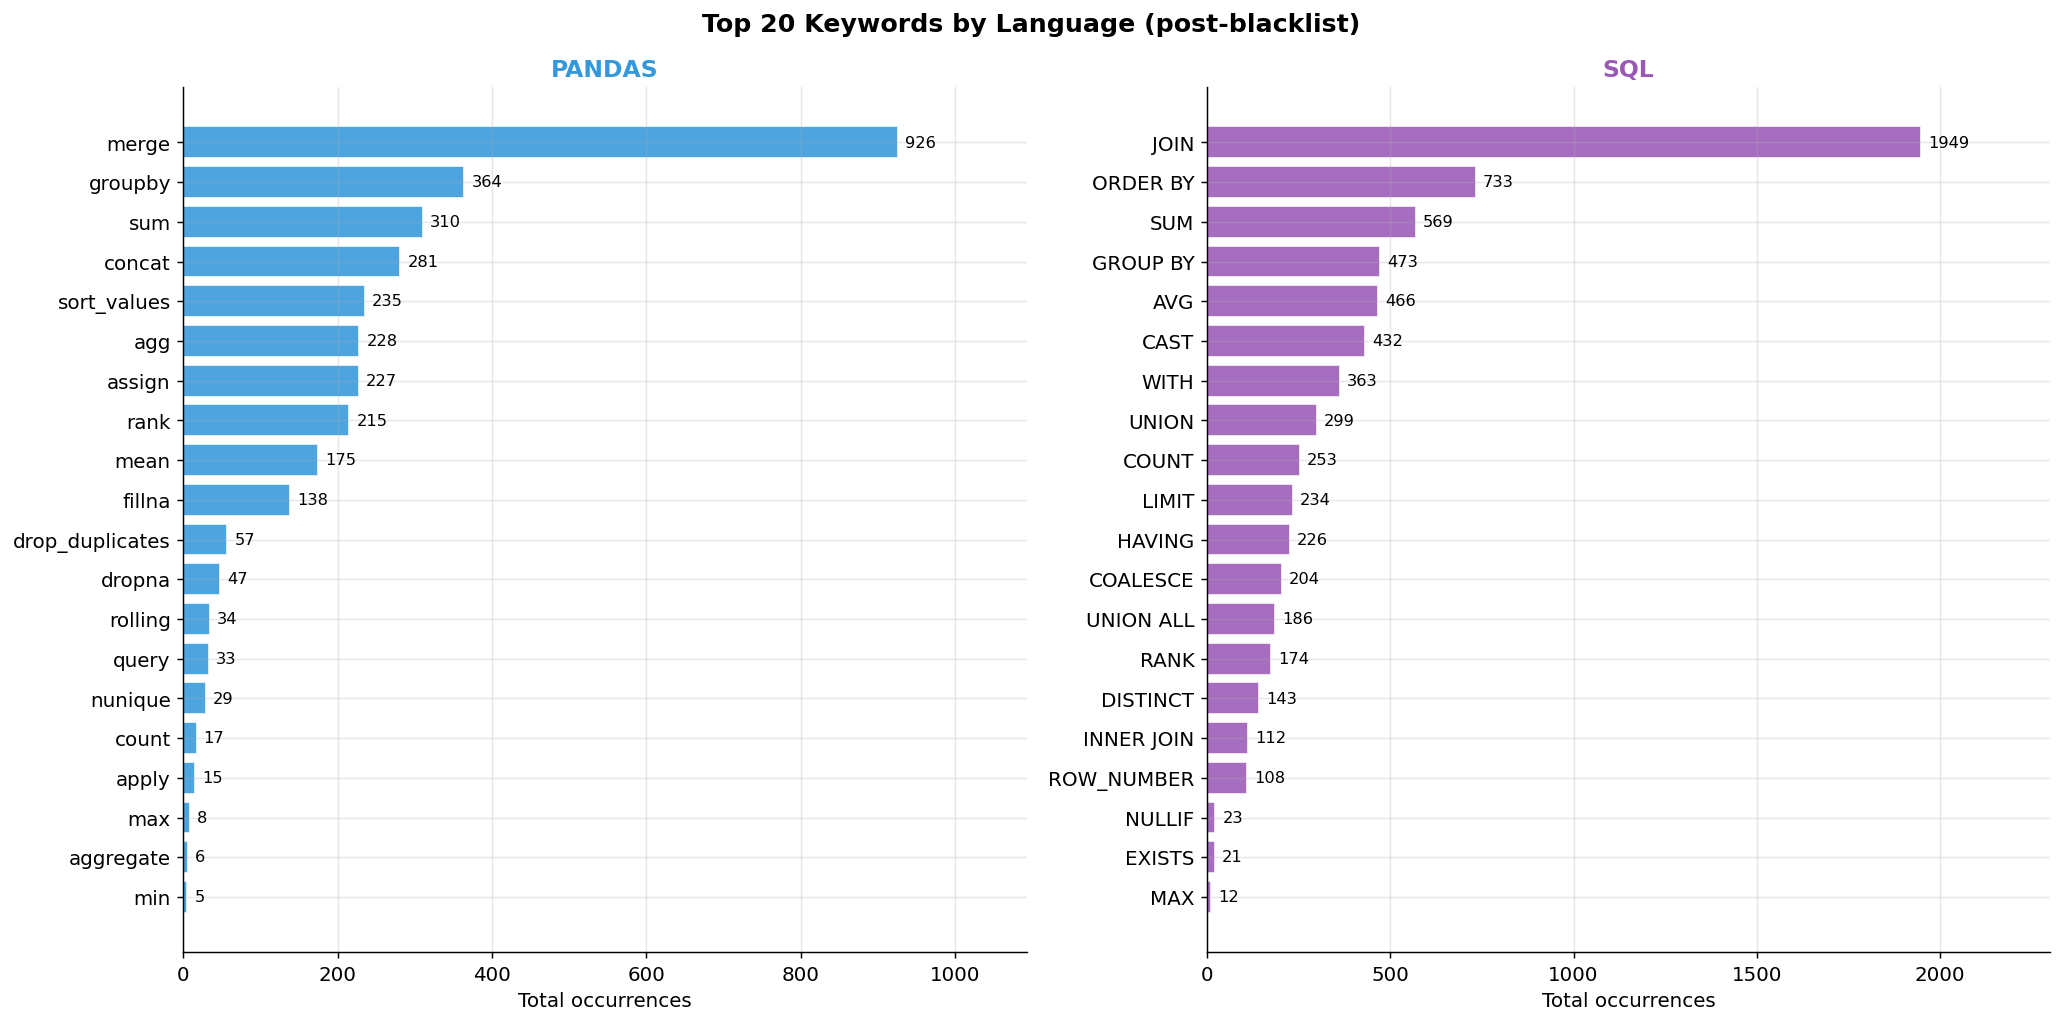

In [21]:
TOP_N = 20
def kw_to_df(counter, top_n=TOP_N):
    return pd.DataFrame(counter.most_common(top_n), columns=['keyword','count'])

df_kp = kw_to_df(kw_pandas)
df_ks = kw_to_df(kw_sql)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f'Top {TOP_N} Keywords by Language (post-blacklist)', fontsize=14, fontweight='bold')

for ax, df_k, lang in zip(axes, [df_kp, df_ks], ['PANDAS','SQL']):
    df_sorted = df_k.sort_values('count')
    bars = ax.barh(df_sorted['keyword'], df_sorted['count'],
                   color=PALETTE[lang], edgecolor='white', alpha=0.88)
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
    ax.set_title(lang, fontsize=13, fontweight='bold', color=PALETTE[lang])
    ax.set_xlabel('Total occurrences')
    ax.set_xlim(0, df_sorted['count'].max()*1.18)

plt.tight_layout(); plt.show()


### 8c. Top Keywords by Model

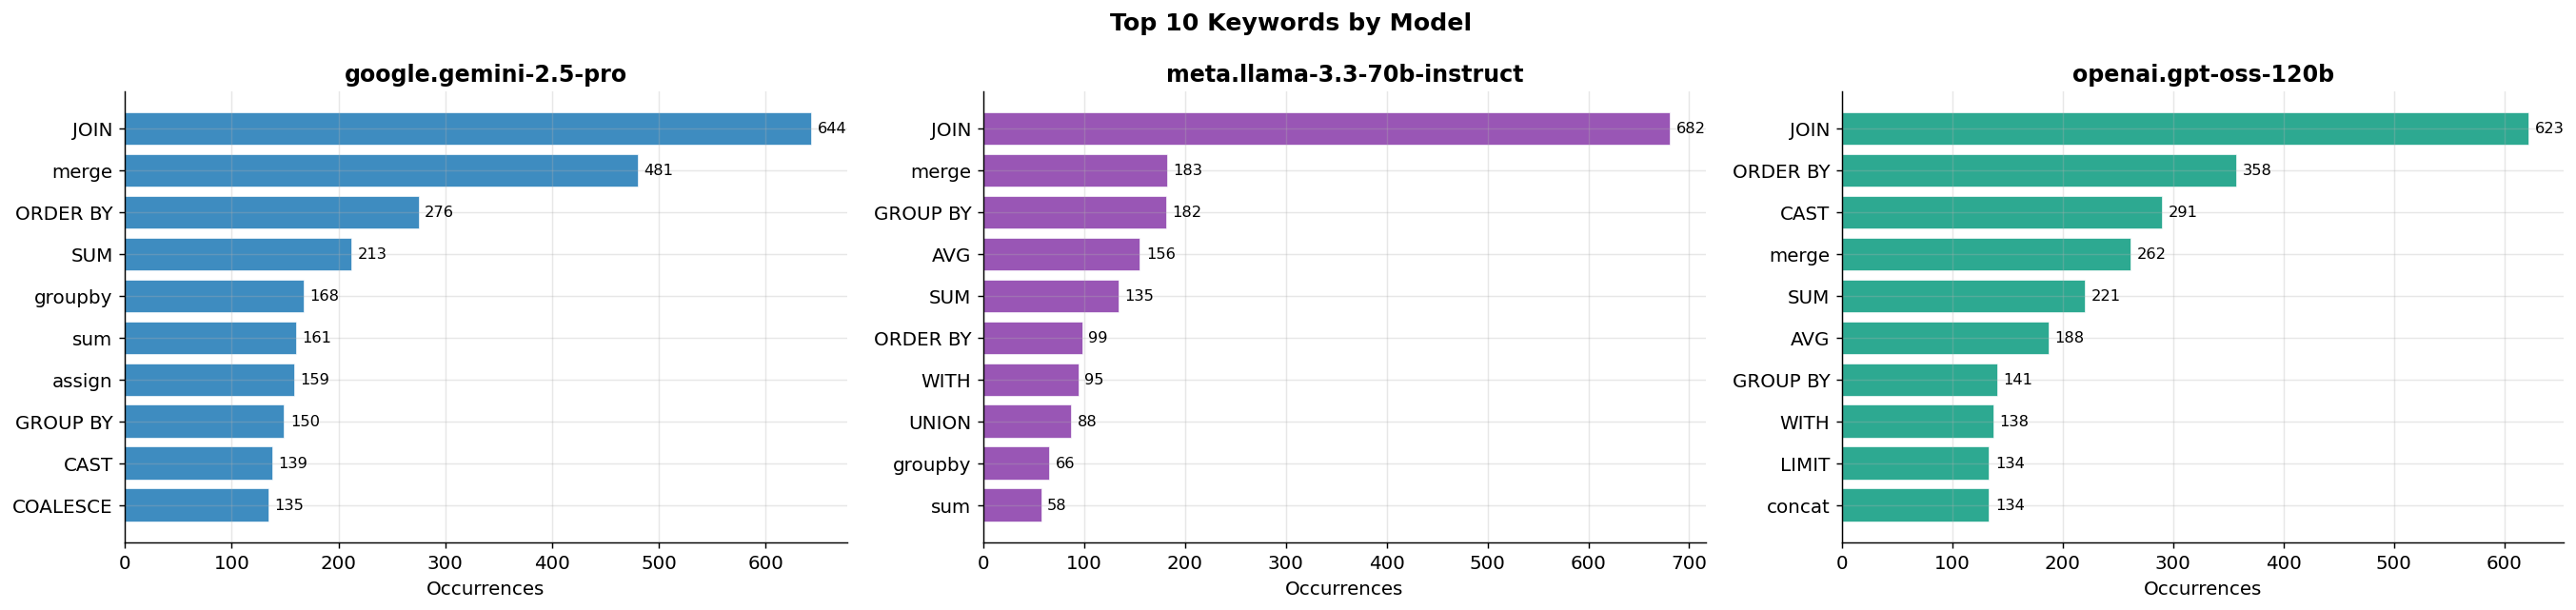

In [22]:
TOP_MODEL = 10
n_models  = len(models)
n_cols    = min(3, n_models)
n_rows    = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = np.array(axes).flatten()
fig.suptitle(f'Top {TOP_MODEL} Keywords by Model', fontsize=14, fontweight='bold')

for ax, m in zip(axes, models):
    sub = df_ok[df_ok['model']==m]
    counter = aggregate_keywords(sub)
    top = counter.most_common(TOP_MODEL)
    if not top:
        ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes)
    else:
        kws, cnts = zip(*top)
        bars = ax.barh(list(reversed(kws)), list(reversed(cnts)),
                       color=MODEL_PALETTE.get(m,'#95A5A6'), edgecolor='white', alpha=0.9)
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
        ax.set_xlabel('Occurrences')
    ax.set_title(m, fontweight='bold')

for ax in axes[n_models:]: ax.set_visible(False)
plt.tight_layout(); plt.show()


### 8d. Keywords by Difficulty × Language

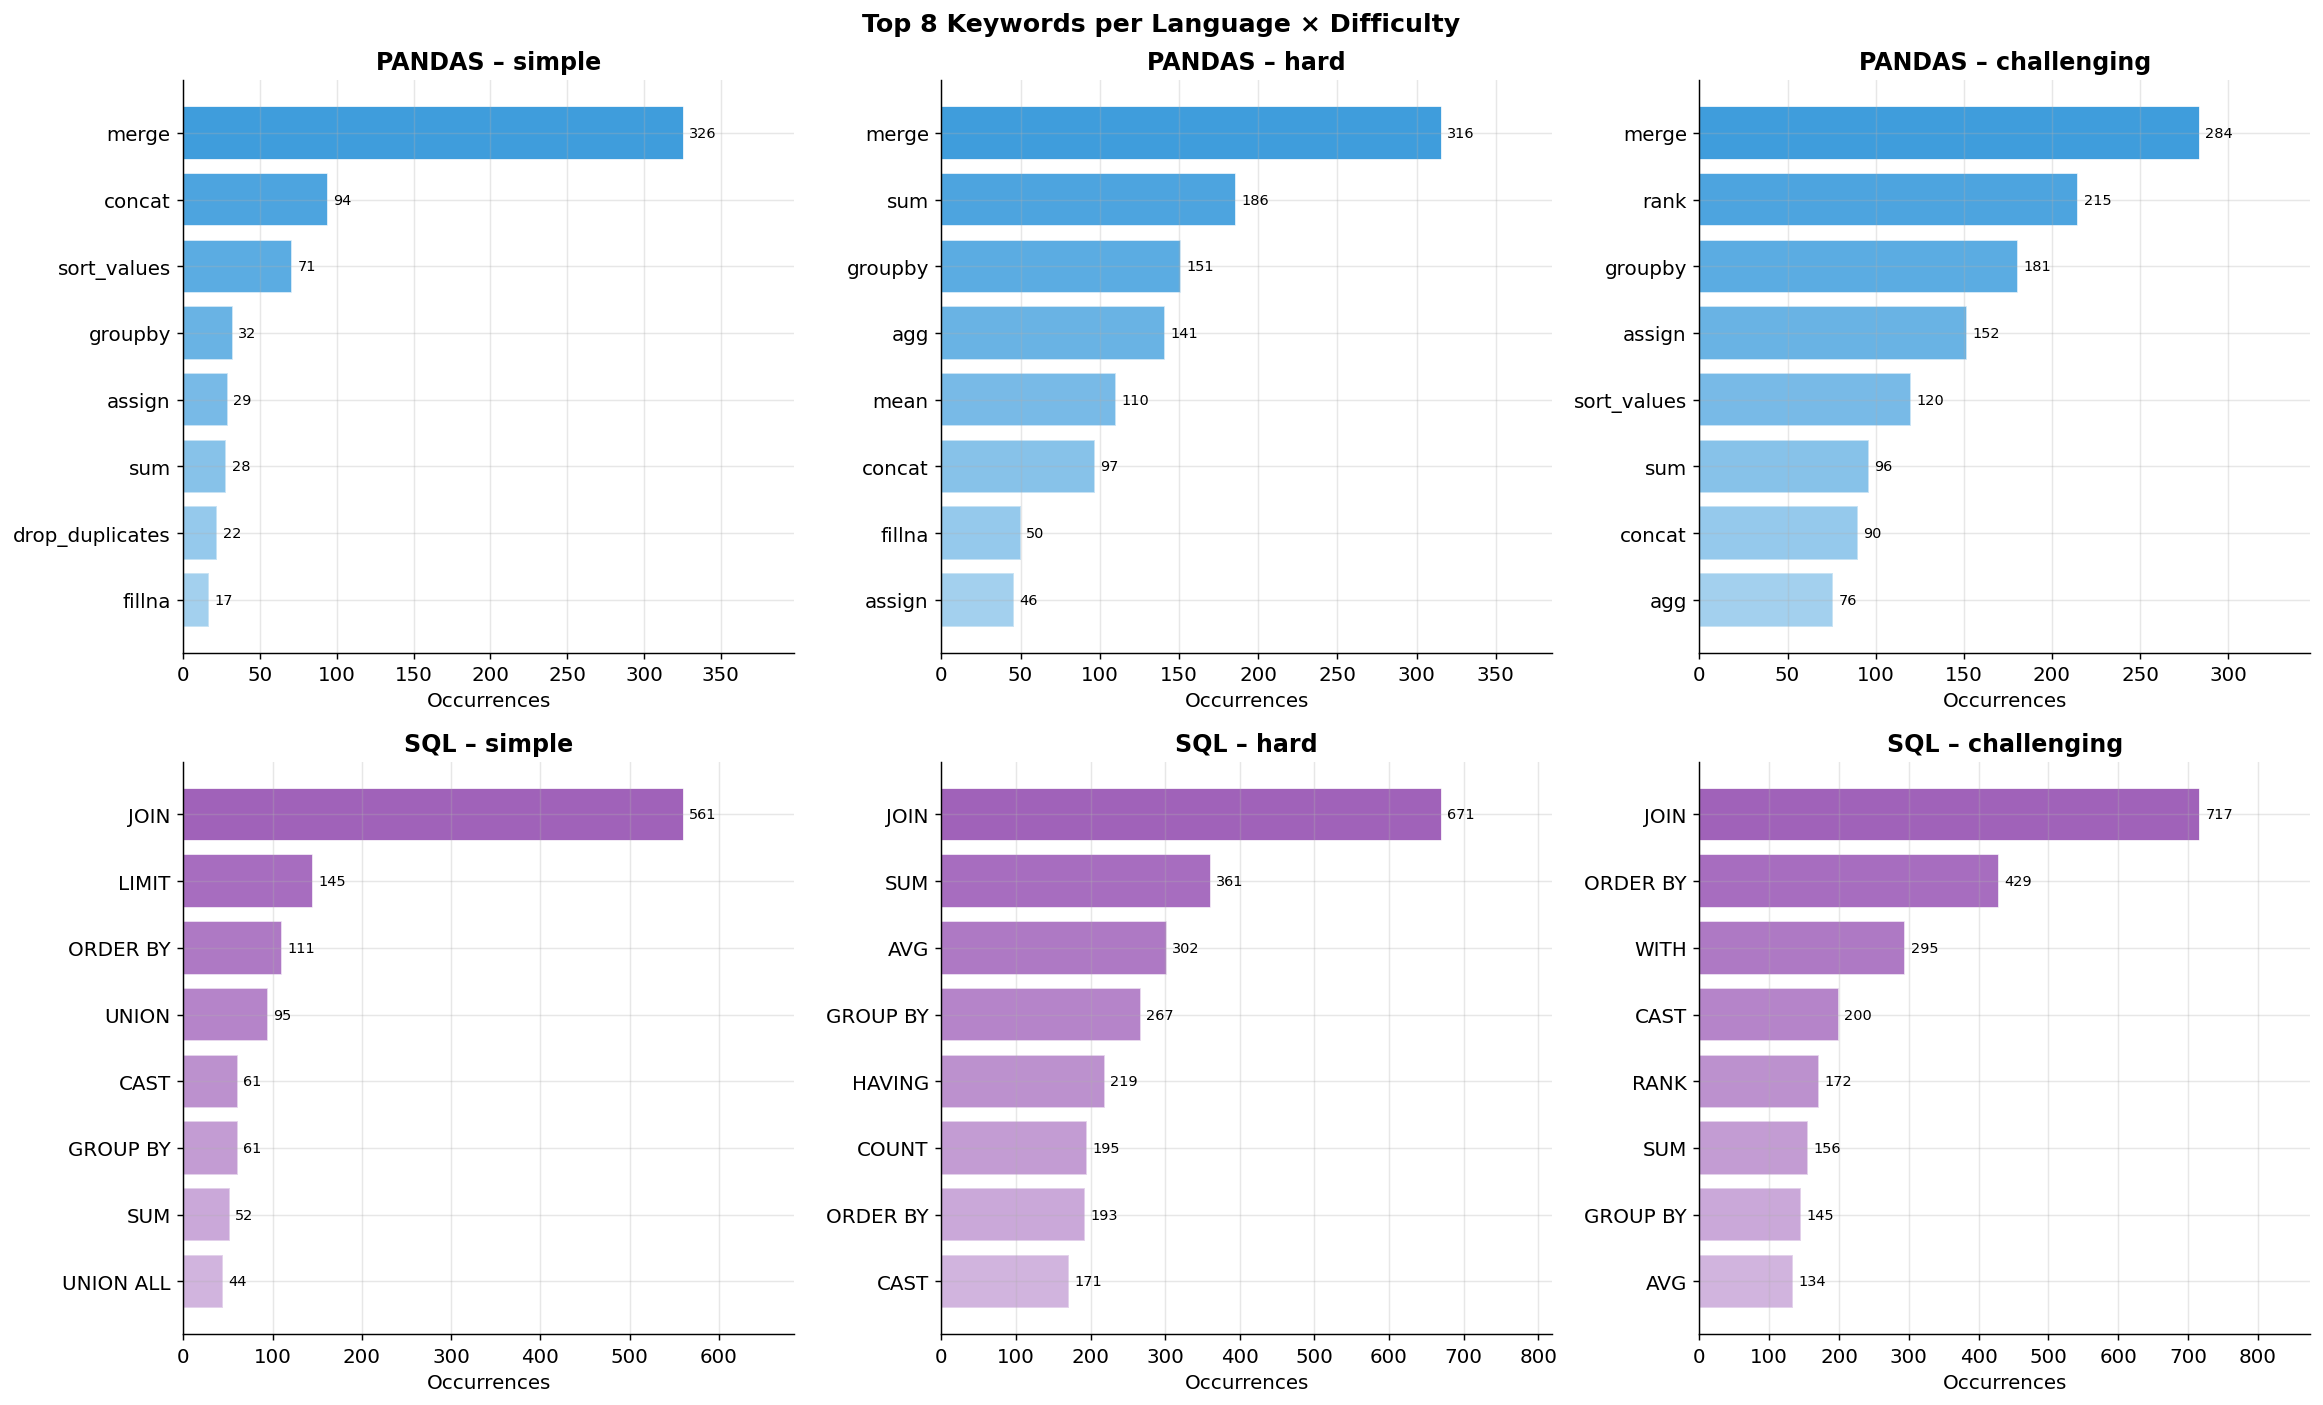

In [23]:
TOP_PER_DIFF = 8
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'Top {TOP_PER_DIFF} Keywords per Language × Difficulty', fontsize=14, fontweight='bold')

for row, lang in enumerate(['PANDAS','SQL']):
    for col, diff in enumerate(DIFF_ORDER):
        ax = axes[row][col]
        subset  = df_ok[(df_ok['language']==lang) & (df_ok['difficulty']==diff)]
        counter = aggregate_keywords(subset)
        top = counter.most_common(TOP_PER_DIFF)
        if not top:
            ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes)
            ax.set_title(f'{lang} – {diff}'); continue
        kws, cnts = zip(*top)
        alphas = np.linspace(0.95, 0.45, len(kws))
        bars = ax.barh(list(reversed(kws)), list(reversed(cnts)),
                       color=PALETTE[lang], edgecolor='white')
        for bar, alpha in zip(bars, reversed(alphas)): bar.set_alpha(alpha)
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
        ax.set_title(f'{lang} – {diff}', fontweight='bold')
        ax.set_xlabel('Occurrences')
        ax.set_xlim(0, max(cnts)*1.22)

plt.tight_layout(); plt.show()
